# Sales & Profit Analysis Using Python

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Load Dataset

In [ ]:
df = pd.read_excel("data/Global_Superstore2.xlsx")

## 4. Data Overview

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,"2,309.65",7,0.00,762.18,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","3,709.39",9,0.10,-288.76,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID","5,175.17",9,0.10,919.97,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless","2,892.51",5,0.10,-96.54,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed","2,832.96",8,0.00,311.52,903.04,Critical


In [21]:
df.shape

(51290, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [19]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,"51,290.00",51290,51290,"51,290.00","51,290.00","51,290.00","51,290.00","51,290.00"
mean,"25,645.50",2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,246.49,3.48,0.14,28.61,26.38
min,1.00,2011-01-01 00:00:00,2011-01-03 00:00:00,0.44,1.00,0.00,"-6,599.98",0.00
25%,"12,823.25",2012-06-19 00:00:00,2012-06-23 00:00:00,30.76,2.00,0.00,0.00,2.61
50%,"25,645.50",2013-07-08 00:00:00,2013-07-12 00:00:00,85.05,3.00,0.00,9.24,7.79
75%,"38,467.75",2014-05-22 00:00:00,2014-05-26 00:00:00,251.05,5.00,0.20,36.81,24.45
max,"51,290.00",2014-12-31 00:00:00,2015-01-07 00:00:00,"22,638.48",14.00,0.85,"8,399.98",933.57
std,"14,806.29",NaN,NaN,487.57,2.28,0.21,174.34,57.30


In [97]:
df.isna().sum()   

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
Year              0
Month             0
dtype: int64

In [96]:
df.duplicated().sum()    

np.int64(0)

## 5. Data Cleaning

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

In [99]:
df = df.drop('Postal Code', axis=1, errors='ignore')

In [16]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [36]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [34]:
df["Year"] = df["Order Date"].dt.year

In [69]:
df["Month"] = df["Order Date"].dt.month

## 6. Exploratory Data Analysis

### 6.1 Overall Performance

In [27]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)

Total Sales: 12642501.909880001
Total Profit: 1467457.29128
Total Quantity: 178312


In [28]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", profit_margin)

Profit Margin: 11.607332960995603


In [22]:
df[["Sales", "Profit", "Discount", "Quantity"]].describe()

,Sales,Profit,Discount,Quantity
count,"51,290.00","51,290.00","51,290.00","51,290.00"
mean,246.49,28.61,0.14,3.48
std,487.57,174.34,0.21,2.28
min,0.44,"-6,599.98",0.00,1.00
25%,30.76,0.00,0.00,2.00
50%,85.05,9.24,0.00,3.00
75%,251.05,36.81,0.20,5.00
max,"22,638.48","8,399.98",0.85,14.00


### 6.2 Category Analysis

category_analysis = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
})

category_analysis

In [23]:
df["Category"].value_counts()

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [26]:
df["Sub-Category"].value_counts()

Sub-Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64

### 6.3 Regional Analysis

In [68]:
region_analysis = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).sort_values("Sales", ascending=False)

region_analysis

,Sales,Profit,Quantity
Region,,,
Central,"2,822,302.52","311,403.98",41762
South,"1,600,907.04","140,355.77",25206
North,"1,248,165.60","194,597.95",18021
Oceania,"1,100,184.61","120,089.11",12838
Southeast Asia,"884,423.17","17,852.33",11822
North Asia,"848,309.78","165,578.42",8851
EMEA,"806,161.31","43,897.97",11517
Africa,"783,773.21","88,871.63",10564
Central Asia,"752,826.57","132,480.19",7715


In [24]:
df["Region"].value_counts()

Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

### 6.3 Segments Analysis

In [100]:
Segment_analysis = df.groupby("Segment").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).sort_values("Sales", ascending=False)

Segment_analysis

,Sales,Profit,Quantity
Segment,,,
Consumer,"6,507,949.42","749,239.78",92157
Corporate,"3,824,697.52","441,208.33",53565
Home Office,"2,309,854.97","277,009.18",32590


In [25]:
df["Segment"].value_counts()

Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

### 6.4 Cities Analysis

In [33]:
City_Profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False)
City_Profit

City
New York City    62,036.98
Los Angeles      30,440.76
Seattle          29,156.10
Managua          17,853.72
San Francisco    17,507.39
                   ...    
Lahore          -13,626.37
Philadelphia    -13,837.77
Tegucigalpa     -15,007.42
Istanbul        -19,960.91
Lagos           -25,922.51
Name: Profit, Length: 3636, dtype: float64

### 6.5 Ship Mode Analysis

In [35]:
Ship_Option = df["Ship Mode"].value_counts()
Ship_Option

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

### 6.6 Customer Analysis

In [91]:
top_customers_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

top_customers_sales.head(10)

Customer Name
Tamara Chand      8,672.90
Raymond Buch      8,453.05
Sanjit Chand      8,205.38
Hunter Lopez      7,816.57
Bill Eplett       7,410.01
Harry Marie       6,958.29
Susan Pistek      6,484.41
Mike Gockenbach   6,458.68
Adrian Barton     6,417.28
Tom Ashbrook      6,311.98
Name: Profit, dtype: float64

In [90]:
top_customers_Profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)

top_customers_Profit.head(10)

Customer Name
Tamara Chand      8,672.90
Raymond Buch      8,453.05
Sanjit Chand      8,205.38
Hunter Lopez      7,816.57
Bill Eplett       7,410.01
Harry Marie       6,958.29
Susan Pistek      6,484.41
Mike Gockenbach   6,458.68
Adrian Barton     6,417.28
Tom Ashbrook      6,311.98
Name: Profit, dtype: float64

### 6.7 Time Analysis

In [62]:
top_Year = df.groupby("Year")["Sales"].sum().sort_values(ascending=False)
top_Year

Year
2014   4,299,865.87
2013   3,405,746.45
2012   2,677,438.69
2011   2,259,450.90
Name: Sales, dtype: float64

In [61]:
top_Year = df.groupby("Year")["Profit"].sum().sort_values(ascending=False)
top_Year

Year
2014   504,165.97
2013   406,935.23
2012   307,415.28
2011   248,940.81
Name: Profit, dtype: float64

### 6.8 Products Analysis

In [41]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

top_products.head(10)

Product Name
Apple Smart Phone, Full Size                               86,935.78
Cisco Smart Phone, Full Size                               76,441.53
Motorola Smart Phone, Full Size                            73,156.30
Nokia Smart Phone, Full Size                               71,904.56
Canon imageCLASS 2200 Advanced Copier                      61,599.82
Hon Executive Leather Armchair, Adjustable                 58,193.48
Office Star Executive Leather Armchair, Adjustable         50,661.68
Harbour Creations Executive Leather Armchair, Adjustable   50,121.52
Samsung Smart Phone, Cordless                              48,653.46
Nokia Smart Phone, with Caller ID                          47,877.79
Name: Sales, dtype: float64

In [66]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

top_products_profit.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                      25,199.93
Cisco Smart Phone, Full Size                               17,238.52
Motorola Smart Phone, Full Size                            17,027.11
Hoover Stove, Red                                          11,807.97
Sauder Classic Bookcase, Traditional                       10,672.07
Harbour Creations Executive Leather Armchair, Adjustable   10,427.33
Nokia Smart Phone, Full Size                                9,938.20
Cisco Smart Phone, with Caller ID                           9,786.64
Nokia Smart Phone, with Caller ID                           9,465.33
Belkin Router, USB                                          8,955.02
Name: Profit, dtype: float64

In [56]:
top_products_quantity = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False)

top_products_quantity.head(10)

Product Name
Staples                                  876
Cardinal Index Tab, Clear                337
Eldon File Cart, Single Width            321
Rogers File Cart, Single Width           262
Sanford Pencil Sharpener, Water Color    259
Stockwell Paper Clips, Assorted Sizes    253
Avery Index Tab, Clear                   252
Ibico Index Tab, Clear                   251
Smead File Cart, Single Width            250
Stanley Pencil Sharpener, Water Color    242
Name: Quantity, dtype: int64

In [86]:
top_products_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

top_products_sales.head(10)

Product Name
Apple Smart Phone, Full Size                               86,935.78
Cisco Smart Phone, Full Size                               76,441.53
Motorola Smart Phone, Full Size                            73,156.30
Nokia Smart Phone, Full Size                               71,904.56
Canon imageCLASS 2200 Advanced Copier                      61,599.82
Hon Executive Leather Armchair, Adjustable                 58,193.48
Office Star Executive Leather Armchair, Adjustable         50,661.68
Harbour Creations Executive Leather Armchair, Adjustable   50,121.52
Samsung Smart Phone, Cordless                              48,653.46
Nokia Smart Phone, with Caller ID                          47,877.79
Name: Sales, dtype: float64

In [72]:
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

product_profit.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8,879.97
Lexmark MX611dhe Monochrome Laser Printer                  -4,589.97
Motorola Smart Phone, Cordless                             -4,447.04
Cubify CubeX 3D Printer Triple Head Print                  -3,839.99
Bevis Round Table, Adjustable Height                       -3,649.89
Bevis Computer Table, Fully Assembled                      -3,509.56
Rogers Lockers, Blue                                       -2,893.49
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2,876.12
Bevis Wood Table, with Bottom Storage                      -2,782.59
Lesro Training Table, Rectangular                          -2,581.28
Name: Profit, dtype: float64

In [73]:
product_analysis = df.groupby("Product Name")[["Sales", "Profit"]].sum()

product_analysis.sort_values("Sales", ascending=False).head(10)

,Sales,Profit
Product Name,,
"Apple Smart Phone, Full Size","86,935.78","5,921.58"
"Cisco Smart Phone, Full Size","76,441.53","17,238.52"
"Motorola Smart Phone, Full Size","73,156.30","17,027.11"
"Nokia Smart Phone, Full Size","71,904.56","9,938.20"
Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93"
"Hon Executive Leather Armchair, Adjustable","58,193.48","5,997.25"
"Office Star Executive Leather Armchair, Adjustable","50,661.68","4,710.98"
"Harbour Creations Executive Leather Armchair, Adjustable","50,121.52","10,427.33"
"Samsung Smart Phone, Cordless","48,653.46",-198.09


### 6.9 Markets Analysis

In [57]:
top_Market_Sales = df.groupby("Market")["Sales"].sum().sort_values(ascending=False)

top_Market_Sales.head(10)

Market
APAC     3,585,744.13
EU       2,938,089.06
US       2,297,200.86
LATAM    2,164,605.17
EMEA       806,161.31
Africa     783,773.21
Canada      66,928.17
Name: Sales, dtype: float64

### 6.10 Discount Analysis

In [51]:
discount_profit = df.groupby("Discount")["Profit"].mean().sort_index()

discount_profit

Discount
0.00       62.05
0.07      140.99
0.10       63.68
0.15       50.60
0.17       38.32
0.20       23.24
0.25        4.04
0.27       -4.32
0.30      -57.90
0.32      -88.56
0.35     -116.14
0.37      -78.46
0.40      -47.30
0.45      -41.61
0.47      -42.98
0.50      -97.14
0.55     -315.07
0.57     -526.13
0.60      -83.22
0.65     -366.00
0.70     -104.34
0.80     -122.20
0.85   -1,534.33
Name: Profit, dtype: float64

In [64]:
discount_Sales = df.groupby("Discount")["Sales"].mean().sort_index()

discount_Sales

Discount
0.00   246.14
0.07   810.78
0.10   388.30
0.15   565.67
0.17   336.60
0.20   242.12
0.25   444.72
0.27   230.29
0.30   555.68
0.32   536.79
0.35   784.48
0.37   427.27
0.40   180.82
0.45   102.11
0.47   115.08
0.50   198.49
0.55   630.87
0.57   678.73
0.60    93.42
0.65   387.05
0.70    78.26
0.80    64.76
0.85   398.42
Name: Sales, dtype: float64

In [70]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
1      675,133.67
2      543,739.38
3      770,500.94
4      698,561.21
5      904,012.34
6    1,269,716.75
7      749,381.84
8    1,293,833.17
9    1,437,380.11
10   1,168,184.39
11   1,551,277.34
12   1,580,780.77
Name: Sales, dtype: float64

In [37]:
Yearly_Sales = df.groupby('Year')['Sales'].sum()
Yearly_Sales

Year
2011   2,259,450.90
2012   2,677,438.69
2013   3,405,746.45
2014   4,299,865.87
Name: Sales, dtype: float64

In [38]:
yearly_profit = df.groupby("Year")["Profit"].sum()

yearly_profit

Year
2011   248,940.81
2012   307,415.28
2013   406,935.23
2014   504,165.97
Name: Profit, dtype: float64

In [53]:
df["Discount"].value_counts().sort_index()

Discount
0.00    29470
0.07      150
0.10     4068
0.15      541
0.17      735
0.20     5039
0.25      198
0.27      388
0.30      340
0.32       27
0.35      122
0.37       74
0.40     3281
0.45      327
0.47      725
0.50     1633
0.55       10
0.57       12
0.60     2029
0.65       17
0.70     1786
0.80      316
0.85        2
Name: count, dtype: int64

## 7.Visualization

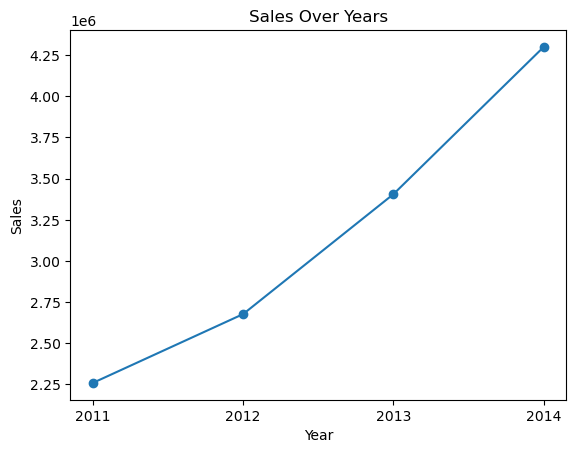

In [79]:
Yearly_Sales.plot(kind="line", marker="o")
plt.title("Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(Yearly_Sales.index)
plt.show()

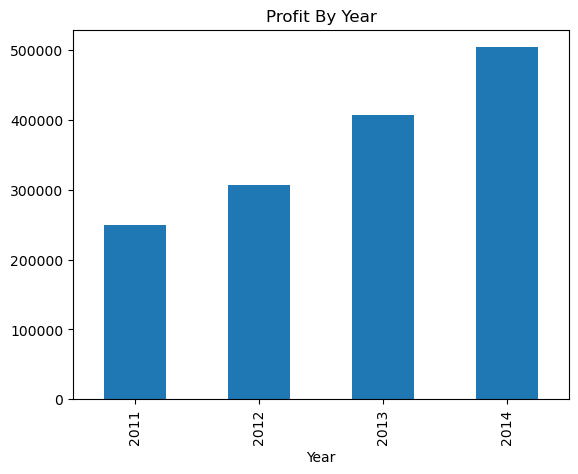

In [152]:
yearly_profit.plot(kind='bar')

plt.title('Profit By Year')
plt.xlabel("Year")
plt.ylabel("Profit")
plt.show()

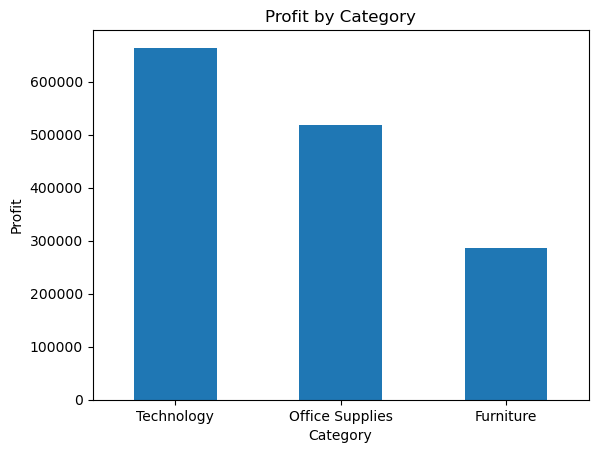

In [80]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

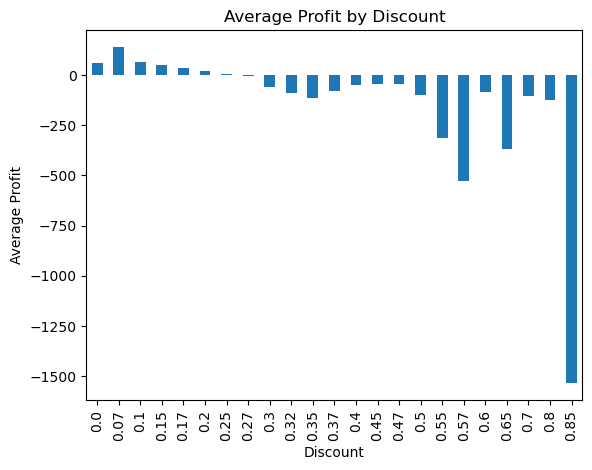

In [54]:
discount_profit.plot(kind="bar")

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

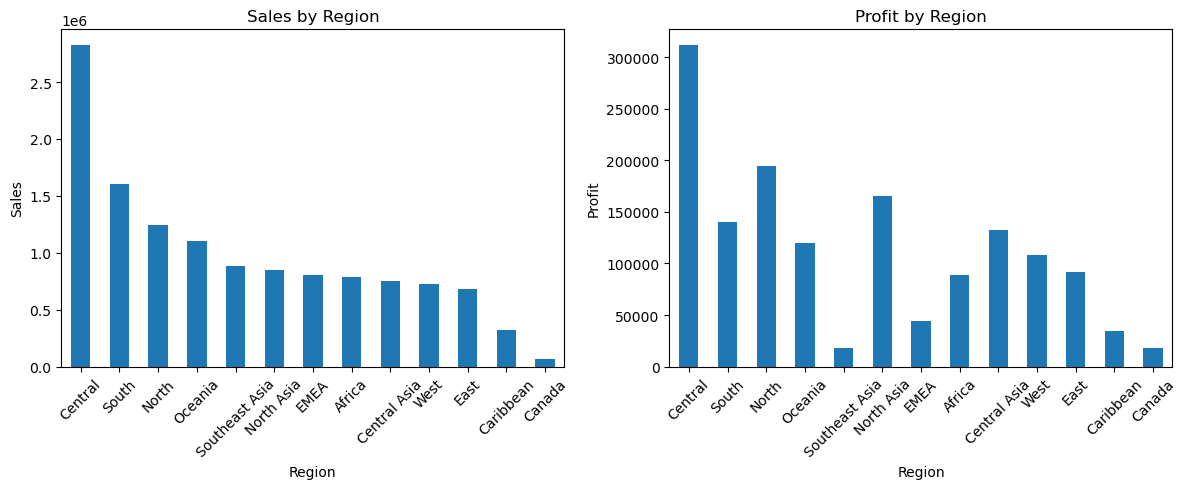

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

region_analysis["Sales"].plot(kind="bar", ax=axes[0])

axes[0].set_title("Sales by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis="x", rotation=45)

region_analysis["Profit"].plot(kind="bar", ax=axes[1])

axes[1].set_title("Profit by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Profit")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

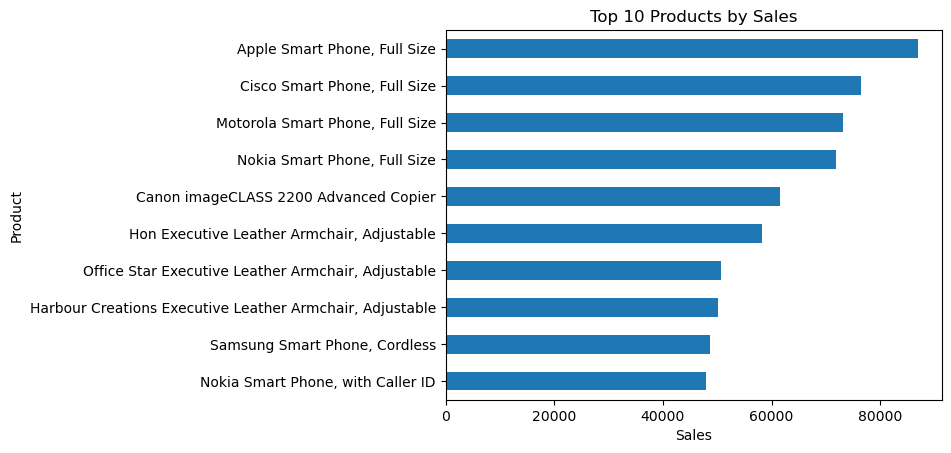

In [87]:
top_products_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

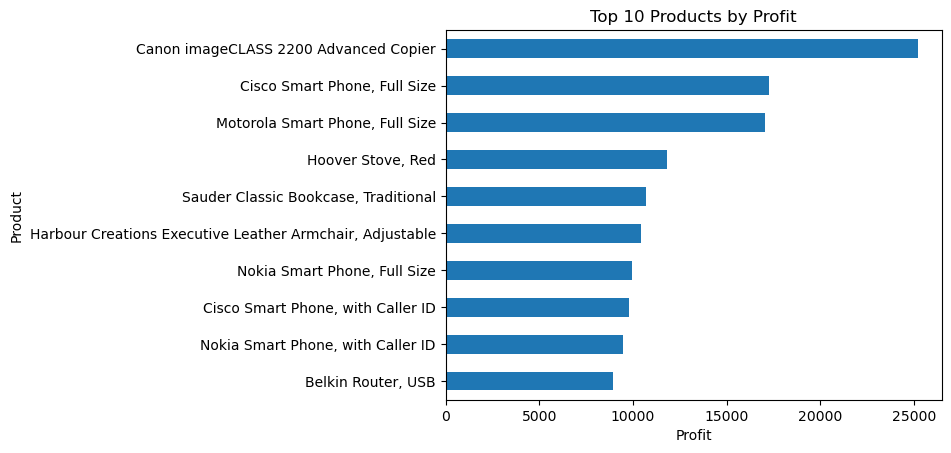

In [88]:
top_products_profit.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

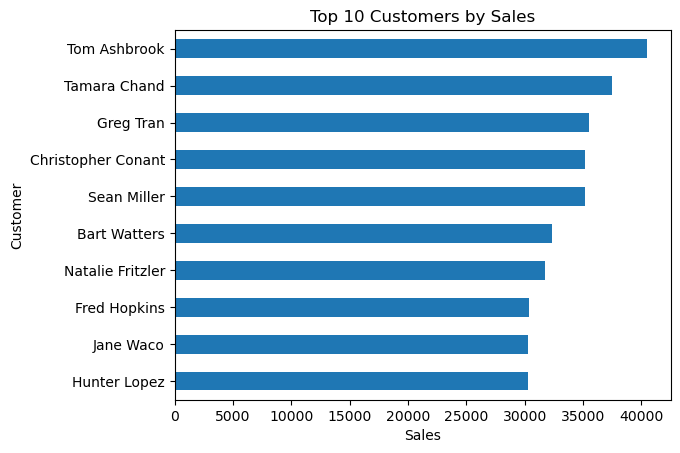

In [92]:
top_customers_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

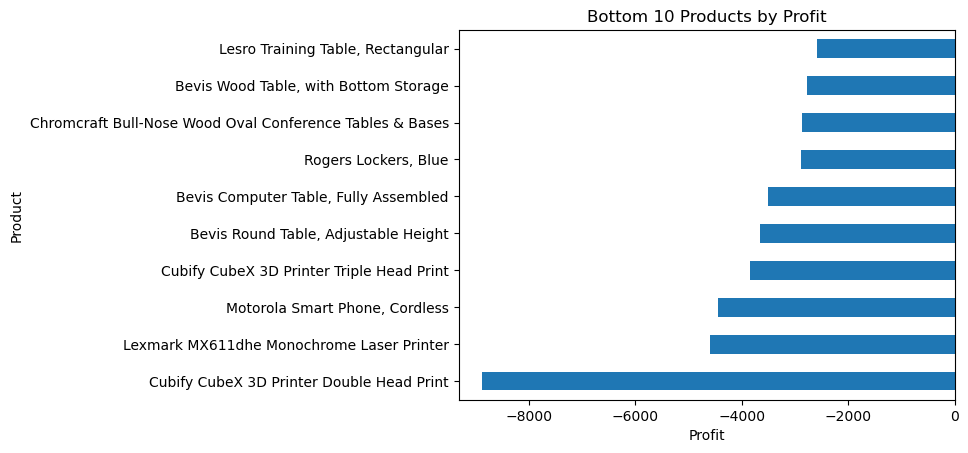

In [94]:
bottom_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

bottom_products_profit.head(10).sort_values().plot(kind="barh")

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

In [49]:
df["Discount"] = df["Discount"].round(2)

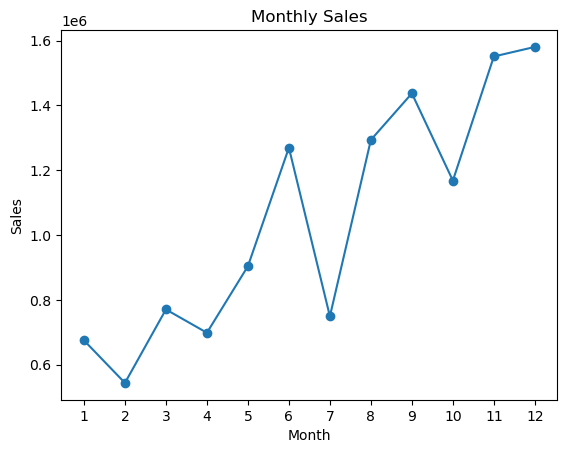

In [93]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(monthly_sales.index)

plt.show()

## 8. Business Insights

### 1. Sales and Profit Performance Over Time
2014 recorded the highest sales and the highest profit among the analyzed years, indicating that overall business performance improved over time.

### 2. Sales Do Not Necessarily Mean Higher Profit
The Central region generated the highest sales, but it was not the most profitable region. This shows that a region with higher sales does not necessarily generate higher profit.

### 3. Discount and Profitability
Higher discount levels were generally associated with lower average profit. At higher discount levels, average profit tended to decrease and in several cases became negative.

However, this relationship should not be interpreted as proof that discounts directly cause losses, since other factors such as product type, cost, pricing, and sales volume may also affect profitability.

### 4. Discount and Sales
Discount levels did not show a clear positive relationship with average sales. Therefore, increasing the discount does not necessarily result in higher average sales.

### 5. High Profit with Low Sales
Some observations showed relatively high profit despite relatively low sales. This does not necessarily indicate a problem. It may suggest that certain transactions or products have higher profit margins, meaning that a smaller sales value can still generate strong profitability.

### 6. Large Negative Profit
The minimum recorded profit was approximately -6,599.98. A large negative profit is not necessarily a data error; it may represent a real transaction or order that resulted in a significant loss.

Such cases may require further investigation into factors such as:
- High discounts
- High product costs
- Pricing decisions
- Product-specific profitability
- Order-level factors

### 7. Product Profitability
The analysis showed that high sales do not always translate into high profit. Some products may generate strong sales while contributing relatively little profit, while other products may generate lower sales but better profitability.

### 8. Underperforming Products
Products with negative total profit represent potential areas for further investigation. Their losses could be related to pricing, costs, discounts, or other product-level factors.

### 9. Business Implication
The analysis suggests that the business should evaluate performance using both sales and profitability rather than relying on sales alone. Monitoring profit margins, discount levels, and product-level profitability can support better pricing and sales decisions.

## 9. Conclusion

This project analyzed sales and profitability data using Python, focusing on data cleaning, exploratory data analysis, aggregation, and data visualization.

The analysis showed that overall business performance improved over time, with 2014 recording the highest sales and profit. However, the results also highlighted that higher sales do not necessarily mean higher profitability, as seen in the regional and product-level analysis.

The discount analysis showed that higher discount levels were generally associated with lower average profit, while no clear positive relationship was found between discount levels and average sales.

The analysis also identified transactions and products with unusually high losses or low profitability. These cases are not necessarily data errors and may require further investigation into factors such as pricing, costs, discounts, and product-level performance.

Overall, this project demonstrates how Python can be used to transform raw business data into meaningful insights that can support better sales, pricing, and profitability decisions.